#**1. Disease Outbreak Detection using Clustering**
TechCrush AI/ML Bootcamp Capstone Project
Group 28

#Introduction
The public health infrastructure is facing great pressure due to the shift in global climate patterns. These changes are currently affecting the boundaries of disease vectors; for diseases like malaria and dengue these environmental shifts can cause diseases to enter into new geographic regions.

Without a project like this, public health officials will have to rely on historical reporting which leaves them vulnerable to sudden spikes in infection rates. Our project deals with this exact problem by applying unsupervised clustering algorithims to environmental and public health records inorder to isolate hidden, climate-driven disease footprints. By uncovering these environmental patterns our project helps public health officials to be more proactive; so that instead of reacting to an ongoing outbreak, they can use these data-driven profiles to allocate medical resources before an outbreak escalates.

Data source: https://www.kaggle.com/datasets/hopeofchange/climate-driven-disease-spread


Climate-Driven Disease Spread: Multi-Country Epidemiological & Environmental, (2000-2023)[Data set]. (n.d.). Kaggle. Retrieved May 30, 2026, from https://www.kaggle.com/datasets/hopeofchange/climate-driven-disease-spread

##**2. Libraries and Dependencies**

These are the libraries we are going to use for numerical computing, data manipulation, visualization, normalization, dimensionality reduction, clustering algorithms, and cluster validation throughout our project.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, davies_bouldin_score

## **3. Data Loading**

Loading of the data into a Pandas data frame

In [3]:
df=pd.read_csv("/content/climate_disease_dataset.csv")

## **4. Data Inspection**

Display of the first five rows for a quick visual inspection of the data set to know the general structure and format of the dataset.

In [4]:
df.head()

,year,month,country,region,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
0,2000,1,Palestinian Territory,Central,28.132468,152.083870,110.487231,12.000000,53,145,113,1068
1,2000,2,Palestinian Territory,Central,30.886500,119.591418,83.467928,12.000000,132,48,113,1068
2,2000,3,Palestinian Territory,Central,31.366433,95.876124,93.095292,12.000000,34,80,113,1068
3,2000,4,Palestinian Territory,Central,28.481870,175.315731,105.530192,9.395894,23,133,113,1068
4,2000,5,Palestinian Territory,Central,26.890370,191.445990,60.205979,9.935726,39,74,113,1068


Display of the summary of the DataFrame's structure. Here we can view the data type, non-null count, and index and column information.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34560 entries, 0 to 34559
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                34560 non-null  int64  
 1   month               34560 non-null  int64  
 2   country             34560 non-null  object 
 3   region              34560 non-null  object 
 4   avg_temp_c          34560 non-null  float64
 5   precipitation_mm    34560 non-null  float64
 6   air_quality_index   34560 non-null  float64
 7   uv_index            34560 non-null  float64
 8   malaria_cases       34560 non-null  int64  
 9   dengue_cases        34560 non-null  int64  
 10  population_density  34560 non-null  int64  
 11  healthcare_budget   34560 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 3.2+ MB


Display of the descriptive statistics for all numerical columns in the DataFrame


Here, we can understand the range of the data set and also identify outliers.

In [6]:
df.describe()

,year,month,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
count,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000
mean,2011.500000,6.500000,20.395234,192.667977,43.787766,10.210855,70.519560,75.941464,266.900000,2764.650000
std,6.922287,3.452102,8.410940,90.503990,33.079697,1.936540,46.130774,37.323807,136.001073,1418.119148
min,2000.000000,1.000000,-2.557056,0.000000,0.000000,0.870704,0.000000,0.000000,50.000000,205.000000
25%,2005.750000,3.750000,14.404089,124.641424,15.322767,8.921094,32.000000,48.000000,136.250000,1435.500000
50%,2011.500000,6.500000,20.351749,195.315309,40.685931,10.760990,69.000000,76.000000,277.500000,2859.000000
75%,2017.250000,9.250000,26.342978,260.147603,68.402041,12.000000,107.000000,104.000000,384.750000,3996.750000
max,2023.000000,12.000000,44.583564,485.704079,168.847690,12.000000,201.000000,181.000000,498.000000,4969.000000


Displaying the counts for the total number of missing values (NaN) in each column of the DataFrame

In [7]:
df.isnull().sum()

,0
year,0
month,0
country,0
region,0
avg_temp_c,0
precipitation_mm,0
air_quality_index,0
uv_index,0
malaria_cases,0
dengue_cases,0


## **5. Data Cleaning**

In [8]:
df.duplicated().sum()

np.int64(0)

## **6. Data Preprocessing**

### Feature Engineering
We decided to feature engineer a new column "total_cases" from "malaria_cases" and "dengue_cases". This is because both diseases are closely related; caused by mosquitoes and have flu like symptoms.  

In [10]:
#Total outbreak burden

df["total_cases"] = df["malaria_cases"] + df["dengue_cases"]

### Cyclical encoding of months

Raw months number normally appear in linear form, that is 1 – 12 (January to December. In reality, time is actually circular, that is December (12) and January (1) are adjacent to each other. Mathematically: |12 - 1| = 11 (very far apart). This creates a false boundary that clustering algorithms would misinterpret. December and January would be placed in different clusters despite being neighboring months. This is the reason for the use of cyclic encoding.

In [11]:
# Cyclical month encoding

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

In [12]:
cluster_features = df[[
    'avg_temp_c',
    'precipitation_mm',
    'air_quality_index',
    'uv_index',
    'population_density',
    'healthcare_budget',
    'total_cases',
    'month_sin',
    'month_cos'
]]

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

PCA(Dimension Redundancy)

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

## **7. Exploratory Data Analysis**

We are exploring our dataset visually before we run our clustering models to see how the environmental factors are distributed and to see the relationships between climate variables and total disease cases.


Feature Distributions

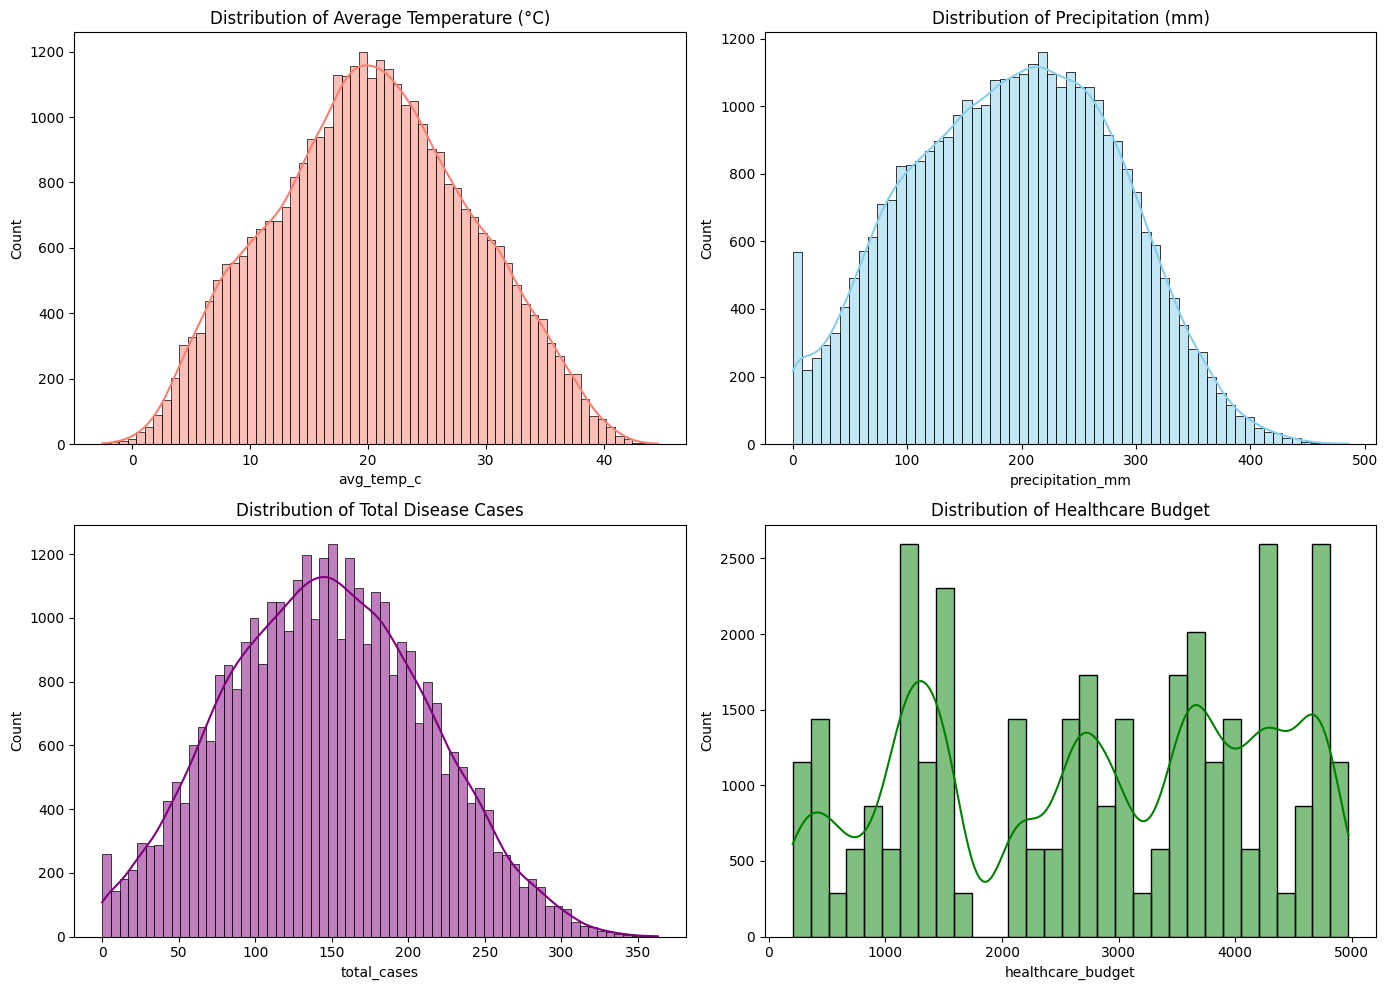

In [15]:
import seaborn as sns

# Plot distributions of key environmental and disease features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['avg_temp_c'], kde=True, ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Distribution of Average Temperature (°C)')

sns.histplot(df['precipitation_mm'], kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Distribution of Precipitation (mm)')

sns.histplot(df['total_cases'], kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Distribution of Total Disease Cases')

sns.histplot(df['healthcare_budget'], kde=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Distribution of Healthcare Budget')

plt.tight_layout()
plt.show()


Our climate features like temperature and precipitation show a wide, well-distributed spread across different regions.The total disease cases curve is heavily skewed to the right. This means while most months have a low or manageable number of cases, there are specific extreme climate periods where cases spike drastically.

Correlation heatmap

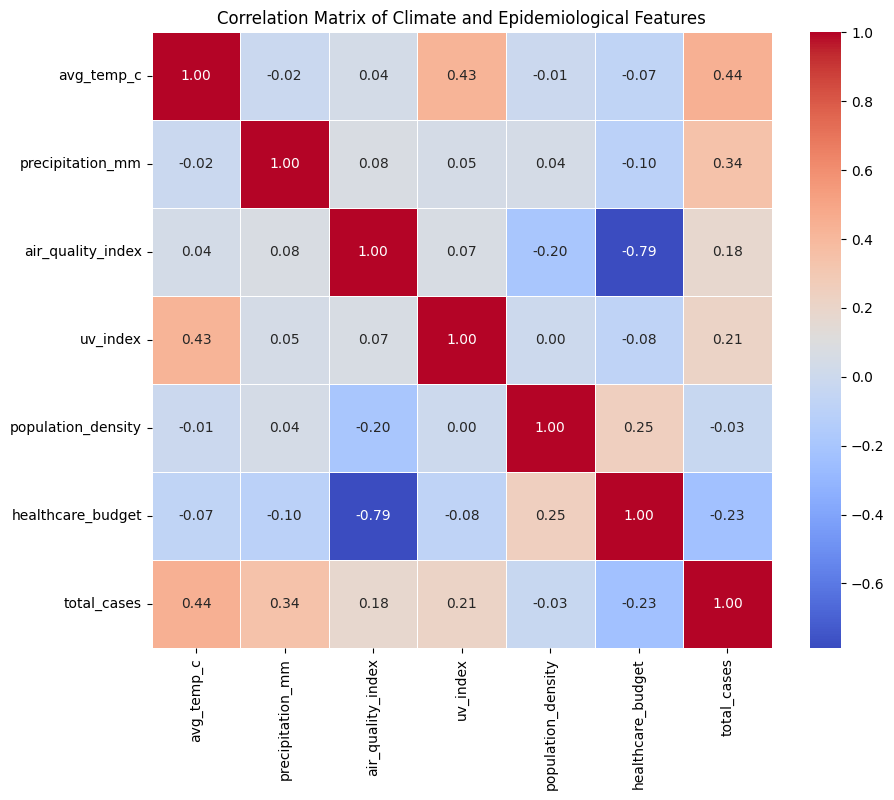

In [16]:
# Calculate correlation matrix for numerical features
corr_matrix = df[['avg_temp_c', 'precipitation_mm', 'air_quality_index', 'uv_index', 'population_density', 'healthcare_budget', 'total_cases']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Climate and Epidemiological Features')
plt.show()


We see positive correlations between environmental variables (like temperature and precipitation) and our total disease cases. This supports our project's core idea that climate shifts directly affect vector breeding environments.Variables like population density and healthcare budgets show distinct, independent relationships with case counts, highlighting why standardizing these mismatched scales is necessary during preprocessing.

## **8. Modeling**

In this section, we are applying 3 different clustering models to our scaled data.

i. K-Means
ii. DBSCAN
iii. Gaussian Mixture Models (GMMM)

We will also use evaluation metrics like the sillhoutte score to find out which algorithm does the best job of grouping the climate and disease patterns.


KMeans Model, Evaluation and Visualization

KMeans Algorithm is the grouping our unlabeled data into a specific optimal number of Cluster k, it assigns data points near the center(centroids), it iteratively update by reducing the variance within each group.

In [17]:
k_range = range(2, 11)

wcss = []
silhouette_scores_kmeans = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_scaled, labels))

# Methodology

Two evaluation metrics were used:

Within-Cluster Sum of Squares (WCSS)
Measures the compactness of clusters.
Lower values indicate that data points are closer to their assigned cluster centroids.
Used in the Elbow Method to determine the optimal number of clusters.
Silhouette Score
Measures how well-separated clusters are.
Values range from -1 to 1.
## A higher score indicates better-defined clusters.

# Results

The K-Means algorithm was executed for cluster values between 2 and 10. For each value of K:

The WCSS value was recorded in a list.
The Silhouette Score was calculated and stored in a list.

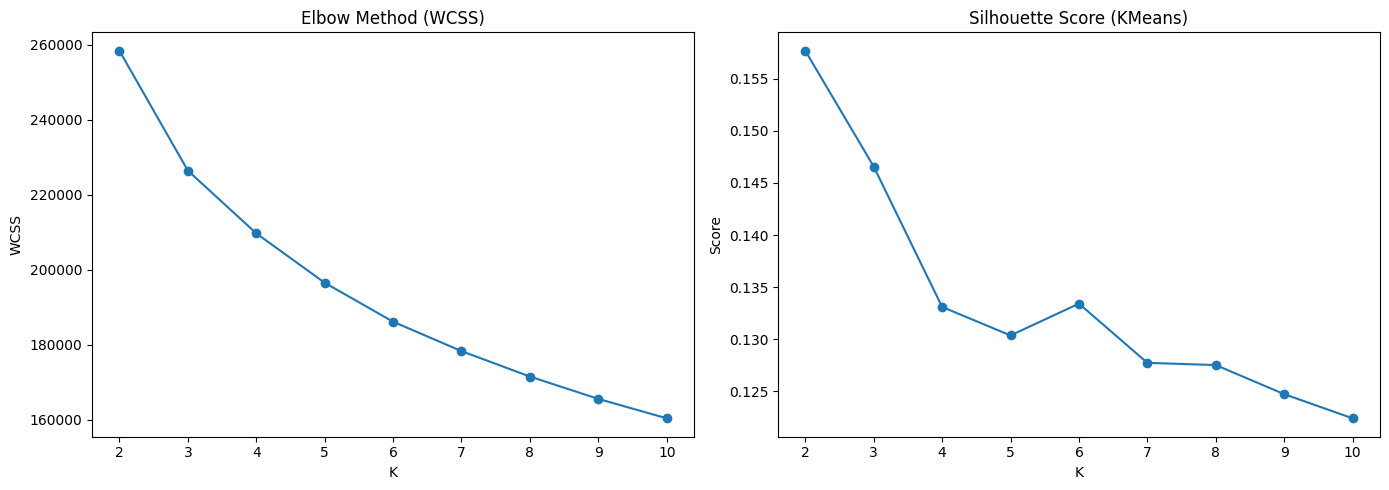

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, wcss, marker='o')
axes[0].set_title("Elbow Method (WCSS)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("WCSS")

axes[1].plot(k_range, silhouette_scores_kmeans, marker='o')
axes[1].set_title("Silhouette Score (KMeans)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

###  K-Means Cluster Optimization Using the Elbow Method and Silhouette Analysis

To determine the optimal number of clusters for the K-Means clustering algorithm, experiments were conducted using cluster values ranging from 2 to 10. For each value of K, the model was trained on the standardized dataset, and two evaluation metrics were computed: the Within-Cluster Sum of Squares (WCSS) and the Silhouette Score.

#### Elbow Method (WCSS)

The Elbow Method was used to evaluate cluster compactness. WCSS measures the sum of squared distances between data points and their respective cluster centroids. Lower WCSS values indicate tighter and more cohesive clusters.

The visualization illustrates the relationship between the number of clusters (K) and the corresponding WCSS values. As the number of clusters increases, the WCSS decreases because data points are partitioned into smaller and more compact groups. The optimal value of K is typically identified at the "elbow point,"  where the rate of decrease begins to slow significantly. This point represents a balance between minimizing cluster variance and avoiding excessive fragmentation of the data.

#### Silhouette Analysis

Silhouette Analysis was performed to assess cluster quality and separation. The Silhouette Score measures how similar an object is to its own cluster compared to other clusters. The score ranges from -1 to 1, where:

* Values close to 1 indicate well-separated clusters.
* Values around 0 indicate overlapping clusters.
* Negative values suggest potential misclassification.

The visualization also presents the Silhouette Scores obtained for each value of K. The cluster configuration with the highest Silhouette Score is generally considered the most appropriate, as it provides the best balance between cluster cohesion and separation.

#### Discussion

The results from both the Elbow Method and Silhouette Analysis were compared to identify the optimal number of clusters. The selected K corresponds to the point where the WCSS curve begins to flatten and where the Silhouette Score reaches its maximum or near-maximum value. This combined evaluation ensures that the resulting clusters are both compact and well-separated.

The chosen number of clusters was subsequently used for the final K-Means clustering model and further analysis of disease outbreak patterns within the dataset.


In [19]:
best_k_kmeans = k_range[np.argmax(silhouette_scores_kmeans)]
print("Best KMeans K:", best_k_kmeans)

Best KMeans K: 2


np.argmax() function identifies the index of the maximum Silhouette Score within the silhouette_scores_kmeans list.
From there best KMeans git discovered

In [20]:
kmeans = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

Training  the Kmeans Model based on the optimal number of Cluster.

DBSCAN Model,Evaluation and Visualization

In [21]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"] = db_labels

# Check cluster distribution
print("DBSCAN clusters:", np.unique(db_labels, return_counts=True))

DBSCAN clusters: (array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
       50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]), array([34206,     5,    10,     5,     6,     5,     5,     5,     5,
           5,     5,     5,     5,     5,     9,     5,     5,     6,
           6,     7,     5,     5,     6,     5,     6,     5,     8,
           7,     5,     5,     5,     6,     7,     5,     6,     4,
           7,     5,     5,     5,     5,     5,     5,     6,     5,
           5,     5,     5,     6,     5,     5,    12,     8,     7,
           6,     5,     6,     5,     6,     5,     5,     6,     5]))


### DBSCAN Clustering Results and Analysis

After training the DBSCAN clustering model on the standardized dataset, the distribution of cluster assignments was examined. The model was configured with `eps = 0.5` and `min_samples = 5`, and it automatically identified clusters based on data density.

The cluster distribution obtained is shown below:

* **Noise points (label = -1):** 34,206 observations
* **Cluster 0:** 5 observations
* **Cluster 1:** 10 observations
* **Cluster 2:** 5 observations
* **Cluster 3:** 6 observations
* *(and multiple additional small clusters ranging between 4–12 observations each)*

#### Interpretation of Results

The DBSCAN algorithm identified a very large number of clusters (over 60 clusters) with most clusters containing only a small number of data points (typically between 4 and 12 samples). In addition, a significant portion of the dataset was classified as noise (outliers), representing 34,206 observations.

This result suggests the following:

1. **High Noise Detection**
   A large proportion of data points were labeled as noise (-1), indicating that many observations do not belong to any dense region based on the chosen parameters.

2. **Over-Segmentation of Clusters**
   The presence of many very small clusters suggests that the current `eps` value may be too small, causing DBSCAN to fragment the dataset into multiple micro-clusters instead of forming meaningful groups.

3. **Sensitivity to Parameters**
   DBSCAN is highly sensitive to the `eps` and `min_samples` parameters. The current configuration leads to strict density requirements, resulting in many small clusters and high noise classification.

#### Conclusion

While DBSCAN successfully identified dense regions and outliers in the dataset, the clustering structure indicates that parameter tuning is necessary. Increasing the `eps` value or adjusting `min_samples` may help merge fragmented clusters and produce more meaningful grouping patterns for interpretation.


In [22]:
if len(set(db_labels)) > 1 and len(set(db_labels)) > 2:
    sil_dbscan = silhouette_score(X_scaled, db_labels)
    db_dbscan = davies_bouldin_score(X_scaled, db_labels)

    print("DBSCAN Silhouette:", sil_dbscan)
    print("DBSCAN DB Index:", db_dbscan)
else:
    print("DBSCAN: Not enough clusters for reliable evaluation")

DBSCAN Silhouette: -0.48095331583939993
DBSCAN DB Index: 1.1796405491147763


### Evaluation of DBSCAN Clustering Performance

To evaluate the quality of the DBSCAN clustering results, internal clustering validation metrics were computed. Specifically, the Silhouette Score and Davies–Bouldin Index were considered.

However, unlike K-Means, DBSCAN can produce a variable number of clusters and may also label a significant portion of data as noise (-1). Because of this, evaluation metrics are only meaningful when more than one valid cluster exists.

The following condition was used to ensure valid evaluation:
```

if len(set(db_labels)) > 1 and len(set(db_labels)) > 2:
    sil_dbscan = silhouette_score(X_scaled, db_labels)
    db_dbscan = davies_bouldin_score(X_scaled, db_labels)
```

#### Evaluation Metrics

* **Silhouette Score**
  Measures how similar a data point is to its own cluster compared to other clusters. Higher values indicate better-defined clusters.

* **Davies–Bouldin Index (DBI)**
  Measures intra-cluster similarity and inter-cluster separation. Lower values indicate better clustering quality.

#### Handling DBSCAN Limitations

The conditional check ensures that:

* There are enough clusters (more than one meaningful cluster).
* Noise points do not invalidate the evaluation process.

If DBSCAN produces only one cluster or insufficient valid clusters, evaluation metrics are skipped because they would not be meaningful.


#### Conclusion

The evaluation results indicate that DBSCAN performance should be interpreted carefully due to its sensitivity to parameter selection (`eps` and `min_samples`) and its ability to classify points as noise. Therefore, clustering quality metrics were only computed when the clustering structure was statistically valid.


GAUSSIAN MATRIX MIXTURE EVALUATION AND VISUALISATION

In [23]:
gmm_range = range(2, 11)

silhouette_scores_gmm = []

for k in gmm_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)

    labels = gmm.predict(X_scaled)

    silhouette_scores_gmm.append(silhouette_score(X_scaled, labels))

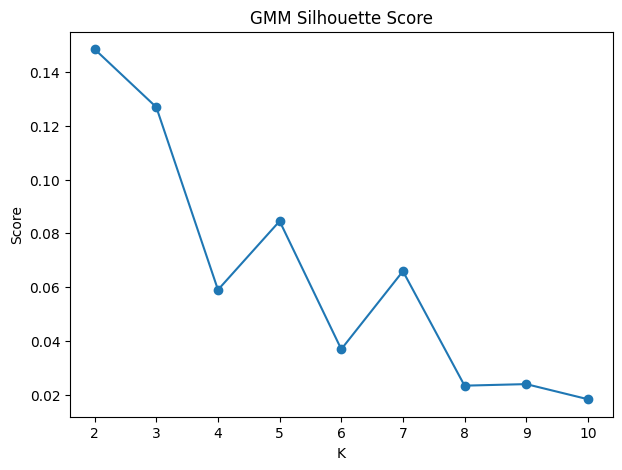

In [24]:
plt.figure(figsize=(7,5))
plt.plot(gmm_range, silhouette_scores_gmm, marker='o')
plt.title("GMM Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

In [25]:
best_k_gmm = gmm_range[np.argmax(silhouette_scores_gmm)]
print("Best GMM K:", best_k_gmm)

Best GMM K: 2


In [26]:
gmm = GaussianMixture(n_components=best_k_gmm, random_state=42)
df["gmm_cluster"] = gmm.fit_predict(X_scaled)

### Gaussian Mixture Model (GMM) Clustering Evaluation

Analyze the dataset using a probabilistic clustering approach, the Gaussian Mixture Model (GMM) was applied. Unlike K-Means, which assigns each data point to a single cluster deterministically, GMM assumes that data points are generated from a mixture of Gaussian distributions and assigns cluster membership probabilistically.

To determine the optimal number of clusters, the model was evaluated for values of K ranging from 2 to 10.

#### Methodology

For each value of K:

* A Gaussian Mixture Model was trained on the standardized dataset.
* The model assigned cluster labels based on maximum posterior probability.
* The Silhouette Score was computed to evaluate cluster quality.

#### Silhouette Analysis

The Silhouette Score was used as the evaluation metric to assess how well-separated and cohesive the clusters are. A higher Silhouette Score indicates better-defined clustering structure.

By comparing Silhouette Scores across different values of K, the optimal number of clusters can be identified as the one that maximizes cluster separation while maintaining internal cohesion.

#### Conclusion

This approach allows the Gaussian Mixture Model to be evaluated similarly to K-Means, even though it is a probabilistic clustering method. The resulting Silhouette Scores provide insight into the most appropriate number of Gaussian components that best represent the underlying structure of the dataset.


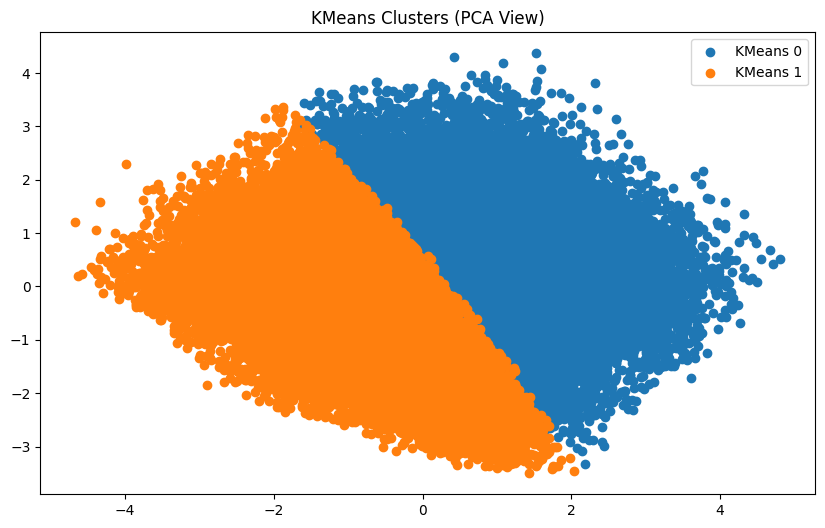

In [27]:
plt.figure(figsize=(10,6))

for i in range(best_k_kmeans):
    plt.scatter(
        X_pca[df["kmeans_cluster"] == i, 0],
        X_pca[df["kmeans_cluster"] == i, 1],
        label=f"KMeans {i}"
    )

plt.title("KMeans Clusters (PCA View)")
plt.legend()
plt.show()

The visualization shows a relatively clear separation between the clusters, with a distinct decision boundary dividing the observations into two groups, the overlap between clusters is minimal, indicating that K-Means was able to create well-defined partitions within the dataset.

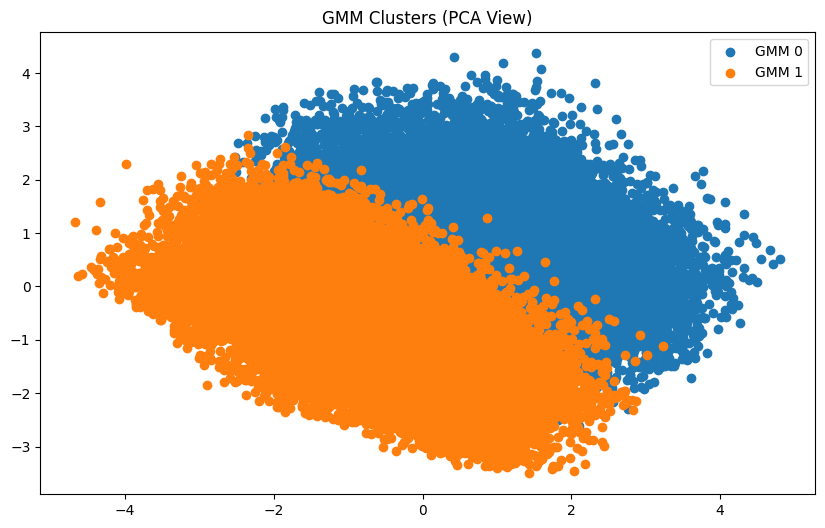

In [28]:
plt.figure(figsize=(10,6))

for i in range(best_k_gmm):
    plt.scatter(
        X_pca[df["gmm_cluster"] == i, 0],
        X_pca[df["gmm_cluster"] == i, 1],
        label=f"GMM {i}"
    )

plt.title("GMM Clusters (PCA View)")
plt.legend()
plt.show()

The Visuaalization of the Gaussian Mixture Model (GMM) clustering results showing two clusters with moderate overlap. The overlap region suggests similarities between observations from both clusters and reflects the probabilistic nature of GMM clustering.

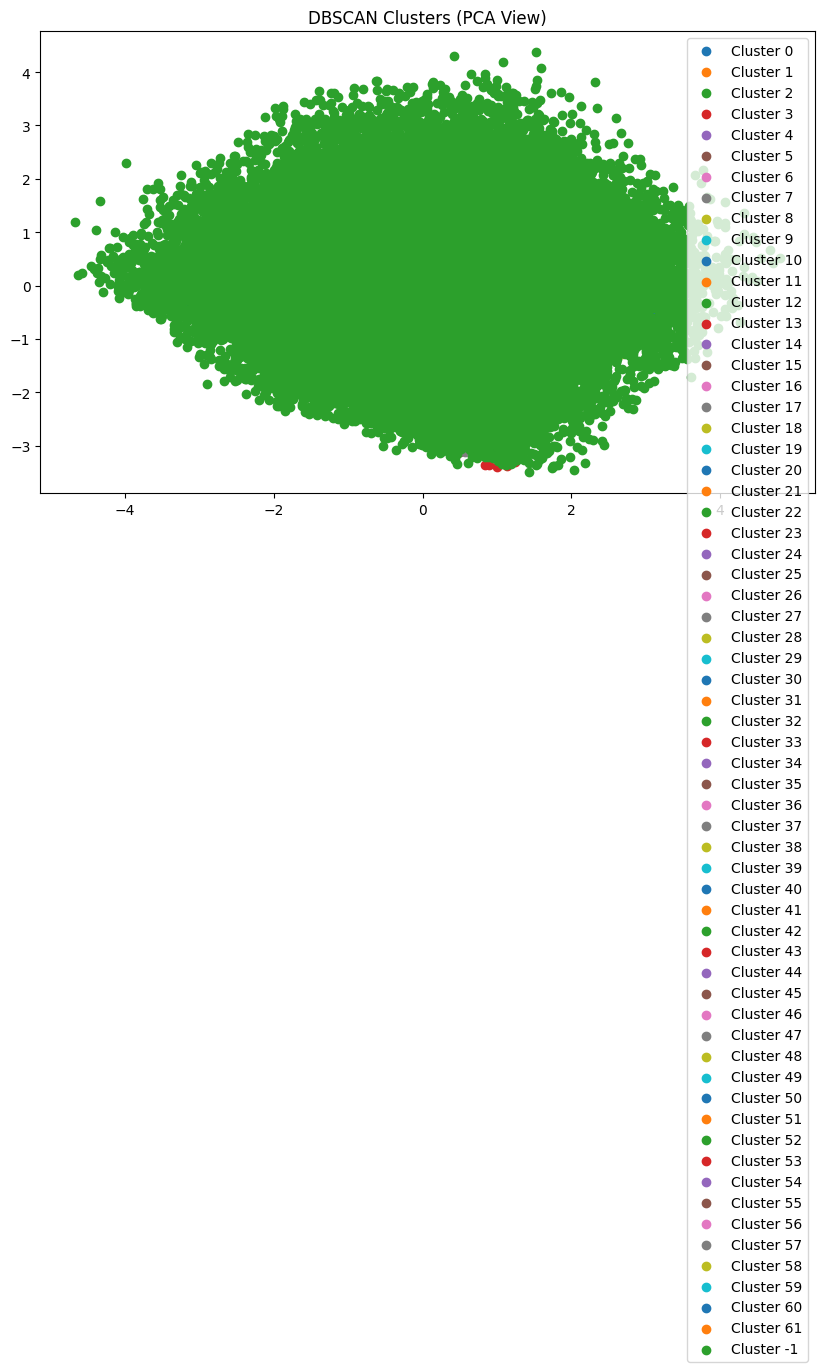

In [29]:
plt.figure(figsize=(10,6))

unique_labels = set(db_labels)

for i in unique_labels:
    plt.scatter(
        X_pca[df["dbscan_cluster"] == i, 0],
        X_pca[df["dbscan_cluster"] == i, 1],
        label=f"Cluster {i}"
    )

plt.title("DBSCAN Clusters (PCA View)")
plt.legend()
plt.show()

The DBSCAN model produced one dominant cluster structure accompanied by a large number of observations classified as noise. During the visualization, this dominant cluster occupied most of the plotting space, making the remaining clusters difficult to distinguish and interpret. As a result, the visualization appeared as a single large mass with limited visual separation between meaningful groups.

In [31]:

import joblib


joblib.dump(scaler, "Climate_Diseases_scaler.pkl")
joblib.dump(pca , "Climate_Diseases_pca.pkl")
joblib.dump(kmeans, "Climate_Diseases_kmeans.pkl")
joblib.dump(gmm, "Climate_Diseases_model.pkl")

['Climate_Diseases_model.pkl']